# Warm-start HP sweep analysis

Reads `results_hparam_sweep_warmstart.csv` (produced by `hparam_sweep_warmstart.py`) and:

1. Inspects basic distributions and failure modes.
2. Bucketises trials by `(loss_type, surrogate_type, optimizer)` and reports per-bucket useful-trial fraction (= gradient improved on warm-start).
3. Picks the winning bucket per loss by mean &gamma; at kept params.
4. Within the winning bucket, picks representative continuous HPs (lr, slope, transform, polyak &alpha;/&beta;, loss-internal HPs).
5. Prints a copy-pasteable `METHOD_CONFIGS` snippet for `benchmark.py`.

Inputs: `../results_hparam_sweep_warmstart.csv`. Outputs: tuned configs, printed at the end. Save figures into `2_thesis/figures/` if useful for the thesis.

## 1. Load & inspect

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV = '../results_hparam_sweep_warmstart.csv'
df = pd.read_csv(CSV)
print(f'rows: {len(df)}')
print(f'kept_source counts:\n{df.kept_source.value_counts(dropna=False)}')
print(f'\ngamma stats:\n{df.gamma.describe()}')
df.head(3)

rows: 1778
kept_source counts:
kept_source
warmstart    1115
training      663
Name: count, dtype: int64

gamma stats:
count    1778.000000
mean        0.011337
std         0.479270
min        -1.000000
25%        -0.388889
50%         0.000000
75%         0.305556
max         1.000000
Name: gamma, dtype: float64


,trial,loss_type,surrogate_type,surrogate_slope,optimizer,learning_rate,use_param_transform,grad_clip_norm,polyak_alpha,polyak_beta,...,train_best_loss,train_final_loss,kept_source,kept_loss,improvement,gamma,n_spikes_sim,n_spikes_gt,n_iter,elapsed_s
0,0,guarino,superspike,2.523943,polyak,0.027189,True,NaN,1.046052,0.094177,...,1.171485,13.455296,warmstart,0.233782,-0.937703,1.000000,9,9,25,2.457486
1,1,guarino,superspike,3.867658,polyak,0.000018,True,NaN,0.947497,0.758088,...,1.179452,1.179483,warmstart,1.019518,-0.159934,0.020761,8,9,25,1.672756
2,2,guarino,superspike,1.663266,polyak,0.000303,True,NaN,0.704334,0.189471,...,0.592785,6465.072266,training,0.592785,0.099918,0.000000,0,9,25,1.585819


In [52]:
# Failure modes
errored = df[df.kept_source == 'ERROR']
non_spiking = df[(df.gamma == 0) & (df.n_spikes_sim == 0)]
nan_gamma = df[df.gamma.isna()]
trained_nan = df[df.train_best_loss.isna() & (df.kept_source != 'ERROR')]
print(f'ERROR runs:                  {len(errored):4d} ({len(errored)/len(df):.0%})')
print(f'training NaN-d at epoch 0:   {len(trained_nan):4d} ({len(trained_nan)/len(df):.0%})')
print(f'gamma is NaN:                {len(nan_gamma):4d} ({len(nan_gamma)/len(df):.0%})')
print(f'gamma == 0 (non-spiking):    {len(non_spiking):4d} ({len(non_spiking)/len(df):.0%})')

ERROR runs:                     0 (0%)
training NaN-d at epoch 0:      9 (1%)
gamma is NaN:                   0 (0%)
gamma == 0 (non-spiking):     208 (12%)


## 2. Useful-trial fraction per bucket

A trial is **useful** if gradient training improved on warm-start: `train_best_loss < warmstart_loss - eps` (with `eps=1e-9`). This is equivalent to `kept_source == 'training'`.

Useful-trial *fraction* per `(loss_type, surrogate_type, optimizer)` bucket tells us which combinations of architectural choices reliably let gradient add value over warm-start alone.

In [53]:
df_ok = df[df.kept_source != 'ERROR'].copy()
df_ok['useful'] = (df_ok.kept_source == 'training')

BUCKETS = ['loss_type', 'surrogate_type', 'optimizer']
agg = (df_ok.groupby(BUCKETS)
             .agg(n_trials=('useful', 'size'),
                  useful_frac=('useful', 'mean'),
                  median_gamma=('gamma', 'median'),
                  median_improvement=('improvement', 'median'),
                  median_kept_loss=('kept_loss', 'median'))
             .reset_index())
agg = agg.sort_values(['loss_type', 'median_gamma'], ascending=[True, False])
agg

,loss_type,surrogate_type,optimizer,n_trials,useful_frac,median_gamma,median_improvement,median_kept_loss
0,guarino,superspike,polyak,880,0.292045,-0.041667,-0.078948,0.577407
1,van_rossum,superspike,polyak,898,0.452116,0.044524,-0.044590,5.052859


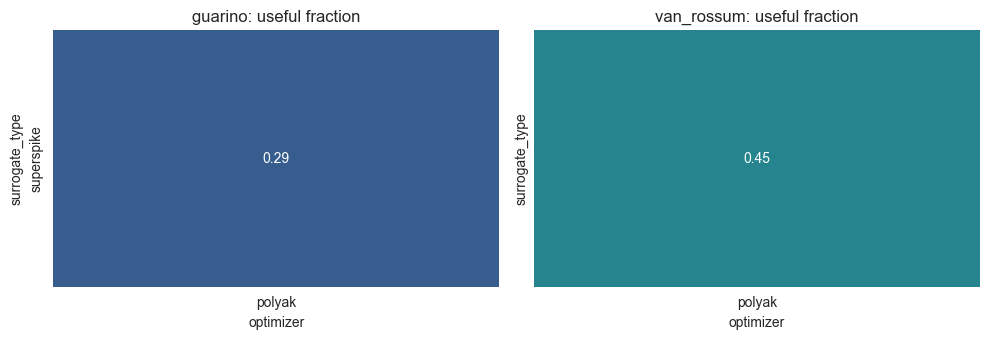

In [54]:
# Heatmap: useful_frac per (surrogate, optimizer), faceted by loss
losses = sorted(df_ok.loss_type.unique())
fig, axes = plt.subplots(1, len(losses), figsize=(5 * len(losses), 3.5), sharey=True)
if len(losses) == 1:
    axes = [axes]
for ax, loss in zip(axes, losses):
    sub = agg[agg.loss_type == loss]
    pivot = sub.pivot(index='surrogate_type', columns='optimizer', values='useful_frac')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
                ax=ax, cbar=False)
    ax.set_title(f'{loss}: useful fraction')
plt.tight_layout(); plt.show()

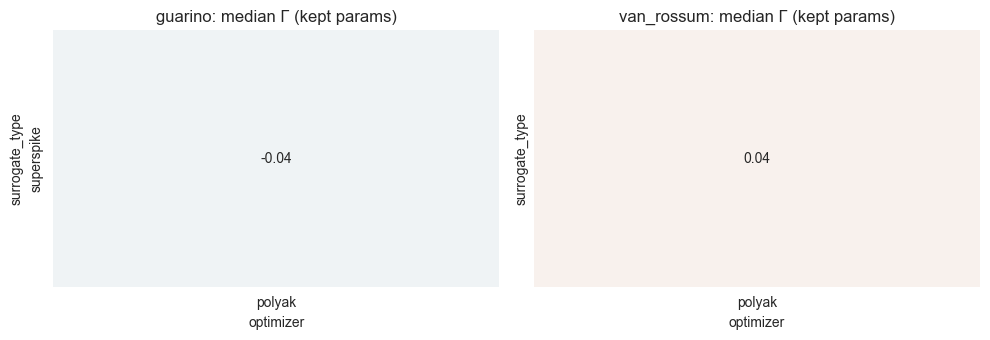

In [55]:
# Heatmap: median gamma per (surrogate, optimizer), faceted by loss
fig, axes = plt.subplots(1, len(losses), figsize=(5 * len(losses), 3.5), sharey=True)
if len(losses) == 1:
    axes = [axes]
for ax, loss in zip(axes, losses):
    sub = agg[agg.loss_type == loss]
    pivot = sub.pivot(index='surrogate_type', columns='optimizer', values='median_gamma')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax, cbar=False)
    ax.set_title(f'{loss}: median \u0393 (kept params)')
plt.tight_layout(); plt.show()

## 3. Pick winning bucket per loss

**Tie-break rule.** Primary: highest mean &gamma; (the metric the thesis cares about). Secondary, when mean &gamma; is within 0.05 of the leader: highest useful_frac (more of a basin under the optimiser, i.e. more robust). Tertiary: lowest median kept_loss.

If no bucket has &gamma; &gt; 0 in expectation, the HP sweep has *not* found a regime where gradient improves on warm-start — flag this and the thesis claim becomes "gradient methods plateau at warm-start quality".

In [56]:
def pick_winner(df_loss, agg_loss):
    """Return the row of agg_loss that best identifies a winning bucket."""
    a = agg_loss.copy()
    a['mean_gamma'] = a.apply(
        lambda r: df_loss[(df_loss.surrogate_type == r.surrogate_type)
                          & (df_loss.optimizer == r.optimizer)].gamma.mean(),
        axis=1)
    a = a.sort_values(['mean_gamma', 'useful_frac', 'median_kept_loss'],
                      ascending=[False, False, True])
    return a.iloc[0]

winners = {}
for loss in losses:
    df_loss = df_ok[df_ok.loss_type == loss]
    agg_loss = agg[agg.loss_type == loss]
    w = pick_winner(df_loss, agg_loss)
    winners[loss] = w
    print(f'\n=== {loss} winner ===')
    print(f'  surrogate_type:    {w.surrogate_type}')
    print(f'  optimizer:         {w.optimizer}')
    print(f'  n_trials in bucket: {w.n_trials}')
    print(f'  useful_frac:       {w.useful_frac:.2%}')
    print(f'  median \u0393:           {w.median_gamma:.3f}')
    print(f'  mean \u0393:             {w.mean_gamma:.3f}')
    print(f'  median improvement: {w.median_improvement:.3f}')
    print(f'  median kept_loss:  {w.median_kept_loss:.3g}')


=== guarino winner ===
  surrogate_type:    superspike
  optimizer:         polyak
  n_trials in bucket: 880
  useful_frac:       29.20%
  median Γ:           -0.042
  mean Γ:             -0.096
  median improvement: -0.079
  median kept_loss:  0.577

=== van_rossum winner ===
  surrogate_type:    superspike
  optimizer:         polyak
  n_trials in bucket: 898
  useful_frac:       45.21%
  median Γ:           0.045
  mean Γ:             0.117
  median improvement: -0.045
  median kept_loss:  5.05


## 4. Pick continuous HPs within each winner

Within a winning `(loss, surrogate, optimizer)` bucket, pick representative values for the continuous HPs. Two strategies:

- **`argmax_gamma`**: take the single trial with the highest &gamma; in the bucket. Simple but noisy with only ~80 trials/bucket.
- **`median_useful`**: take the median of *useful* (`kept_source=='training'`) trials. More robust; reflects "what range of HPs reliably helps".

Default to `median_useful`; fall back to `argmax_gamma` if there are <10 useful trials in the bucket.

In [57]:
CONTINUOUS_SHARED = ['surrogate_slope', 'learning_rate']
OPTIMIZER_SPECIFIC = {'polyak': ['polyak_alpha', 'polyak_beta'],
                      'adam':   ['grad_clip_norm']}
LOSS_SPECIFIC = {'guarino':    ['temperature', 'feature_beta', 'validity_beta', 'weight_spike_count'],
                  'van_rossum': ['tau_ms', 'weight_subthreshold']}

def hps_for(winner_row, df_ok):
    loss, surr, opt = winner_row.loss_type, winner_row.surrogate_type, winner_row.optimizer
    bucket = df_ok[(df_ok.loss_type == loss) & (df_ok.surrogate_type == surr)
                   & (df_ok.optimizer == opt)]
    useful = bucket[bucket.useful]
    fallback = len(useful) < 10
    src = bucket if fallback else useful
    src_label = f'argmax_gamma over {len(bucket)}' if fallback else f'median over {len(useful)} useful'
    if fallback:
        src = src.sort_values('gamma', ascending=False).head(1)
    cols = (CONTINUOUS_SHARED + OPTIMIZER_SPECIFIC.get(opt, []) + LOSS_SPECIFIC.get(loss, []))
    out = {}
    for c in cols:
        if c == 'grad_clip_norm':
            non_null = src[c].dropna()
            out[c] = float(non_null.median()) if len(non_null) > 0 else None
        elif fallback:
            out[c] = float(src.iloc[0][c]) if pd.notna(src.iloc[0][c]) else None
        else:
            out[c] = float(src[c].median()) if src[c].notna().any() else None
    # use_param_transform: majority vote among useful (or argmax_gamma trial)
    out['use_param_transform'] = bool(round(src['use_param_transform'].astype(int).mean())) \
        if not fallback else bool(src.iloc[0]['use_param_transform'])
    out['_src_label'] = src_label
    return out

tuned = {loss: hps_for(w, df_ok) for loss, w in winners.items()}
for loss, hp in tuned.items():
    print(f'\n=== {loss} tuned HPs ({hp["_src_label"]}) ===')
    for k, v in hp.items():
        if k == '_src_label': continue
        print(f'  {k:<22} = {v}')


=== guarino tuned HPs (median over 257 useful) ===
  surrogate_slope        = 2.66463553522462
  learning_rate          = 0.001855120824343
  polyak_alpha           = 0.7453122397591929
  polyak_beta            = 0.4945154704089172
  temperature            = 0.2560289870720196
  feature_beta           = 10.361449096177523
  validity_beta          = 9.504370170578254
  weight_spike_count     = 0.1503627400615393
  use_param_transform    = True

=== van_rossum tuned HPs (median over 406 useful) ===
  surrogate_slope        = 3.485433139949752
  learning_rate          = 0.00125827966063885
  polyak_alpha           = 0.7943469292604791
  polyak_beta            = 0.4863526625128139
  tau_ms                 = 8.435784420386288
  weight_subthreshold    = 0.589463106239651
  use_param_transform    = True


## 5. Copy-pasteable `METHOD_CONFIGS` snippet

Drop into `5_code/benchmark.py` to replace the existing `METHOD_CONFIGS` entries for `grad_guarino` and `grad_vanrossum`. Verify by running the Tue-morning smoke test (1 scenario × 4 methods × 3 inits) before launching the headline benchmark.

In [58]:
def fmt_method_config(loss_key, loss_type, hp, winner):
    """Format a METHOD_CONFIGS entry. Mirrors benchmark.py's expected schema."""
    lines = [f'    "grad_{loss_key}": {{']
    lines.append(f'        "loss_type": "{loss_type}",')
    lines.append(f'        "surrogate_type": "{winner.surrogate_type}",')
    lines.append(f'        "surrogate_slope": {hp["surrogate_slope"]:.4g},')
    lines.append(f'        "optimizer": "{winner.optimizer}",')
    lines.append(f'        "learning_rate": {hp["learning_rate"]:.4g},')
    lines.append(f'        "use_param_transform": {hp["use_param_transform"]},')
    if winner.optimizer == 'polyak':
        lines.append(f'        "polyak_alpha": {hp["polyak_alpha"]:.4g},')
        lines.append(f'        "polyak_beta": {hp["polyak_beta"]:.4g},')
    if winner.optimizer == 'adam':
        gc = hp.get('grad_clip_norm')
        gc_repr = f'{gc:.4g}' if gc is not None else 'None'
        lines.append(f'        "grad_clip_norm": {gc_repr},')
    if loss_type == 'guarino':
        lines.append(f'        "temperature": {hp["temperature"]:.4g},')
        lines.append(f'        "beta": {hp["feature_beta"]:.4g},')
        lines.append(f'        "validity_beta": {hp["validity_beta"]:.4g},')
        lines.append(f'        "weight_spike_count": {hp["weight_spike_count"]:.4g},')
    if loss_type == 'van_rossum':
        lines.append(f'        "loss_kwargs": {{')
        lines.append(f'            "tau_ms": {hp["tau_ms"]:.4g},')
        lines.append(f'            "weight_subthreshold": {hp["weight_subthreshold"]:.4g},')
        lines.append(f'        }},')
    lines.append('    },')
    return '\n'.join(lines)

loss_key_map = {'guarino': 'guarino', 'van_rossum': 'vanrossum'}
print('# --- Drop into benchmark.py METHOD_CONFIGS ---\n')
for loss in losses:
    print(fmt_method_config(loss_key_map[loss], loss, tuned[loss], winners[loss]))
    print()

# --- Drop into benchmark.py METHOD_CONFIGS ---

    "grad_guarino": {
        "loss_type": "guarino",
        "surrogate_type": "superspike",
        "surrogate_slope": 2.665,
        "optimizer": "polyak",
        "learning_rate": 0.001855,
        "use_param_transform": True,
        "polyak_alpha": 0.7453,
        "polyak_beta": 0.4945,
        "temperature": 0.256,
        "beta": 10.36,
        "validity_beta": 9.504,
        "weight_spike_count": 0.1504,
    },

    "grad_vanrossum": {
        "loss_type": "van_rossum",
        "surrogate_type": "superspike",
        "surrogate_slope": 3.485,
        "optimizer": "polyak",
        "learning_rate": 0.001258,
        "use_param_transform": True,
        "polyak_alpha": 0.7943,
        "polyak_beta": 0.4864,
        "loss_kwargs": {
            "tau_ms": 8.436,
            "weight_subthreshold": 0.5895,
        },
    },



## 6. (Optional) HP sensitivity diagnostics

How does each continuous HP separate useful from non-useful trials? If a HP shows clean separation, the sweep is finding a real signal; if distributions overlap heavily, the HP is irrelevant or other HPs dominate.

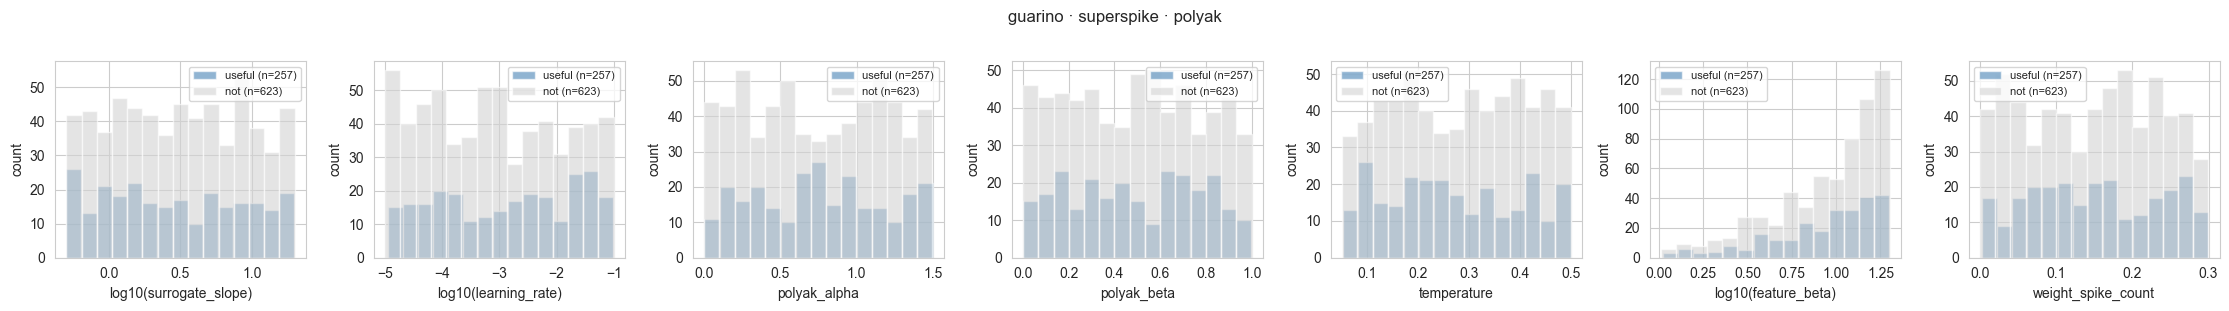

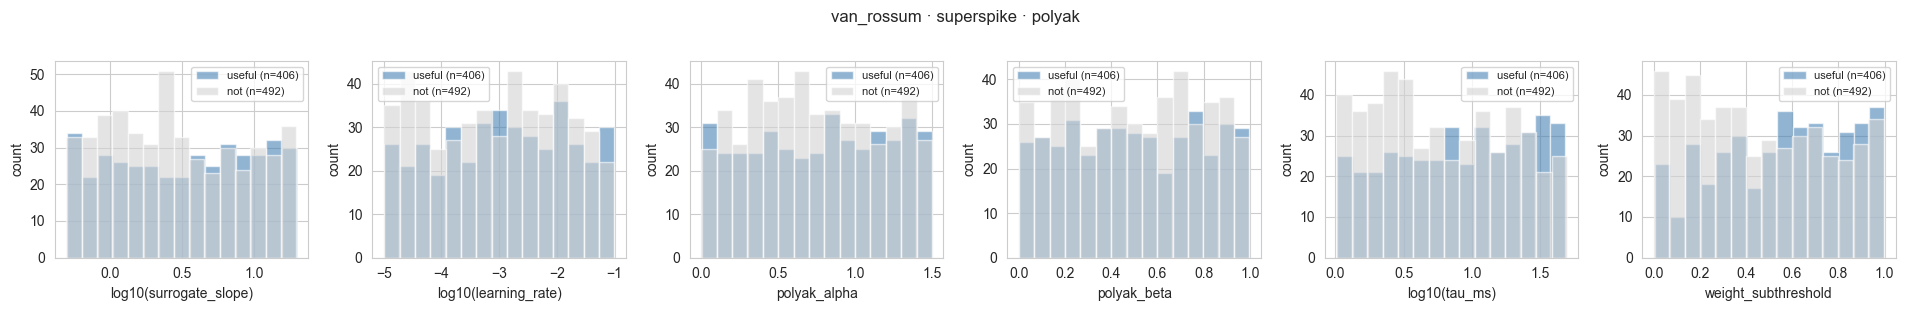

In [59]:
# Within the winning bucket per loss, plot useful-vs-not distributions for key HPs.
for loss in losses:
    w = winners[loss]
    bucket = df_ok[(df_ok.loss_type == loss) & (df_ok.surrogate_type == w.surrogate_type)
                   & (df_ok.optimizer == w.optimizer)].copy()
    if len(bucket) < 5:
        continue
    cols = ['surrogate_slope', 'learning_rate']
    if w.optimizer == 'polyak':
        cols += ['polyak_alpha', 'polyak_beta']
    if loss == 'guarino':
        cols += ['temperature', 'feature_beta', 'weight_spike_count']
    if loss == 'van_rossum':
        cols += ['tau_ms', 'weight_subthreshold']
    fig, axes = plt.subplots(1, len(cols), figsize=(3.2 * len(cols), 3))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        for tag, sub, color in [('useful', bucket[bucket.useful], 'steelblue'),
                                 ('not',    bucket[~bucket.useful], 'lightgray')]:
            if len(sub) == 0:
                continue
            vals = sub[col].dropna()
            if col in ('learning_rate', 'surrogate_slope', 'tau_ms', 'feature_beta'):
                vals = np.log10(vals[vals > 0])
                xlab = f'log10({col})'
            else:
                xlab = col
            ax.hist(vals, bins=15, alpha=0.6, label=f'{tag} (n={len(sub)})', color=color)
        ax.set_xlabel(xlab); ax.set_ylabel('count')
        ax.legend(fontsize=8)
    fig.suptitle(f'{loss} · {w.surrogate_type} · {w.optimizer}', y=1.02)
    plt.tight_layout(); plt.show()

In [60]:
# Sanity: are there *any* trials with gamma > 0.5? If so, what HPs do they share?
good = df_ok[df_ok.gamma > 0.5]
print(f'trials with \u0393 > 0.5: {len(good)} / {len(df_ok)} ({len(good)/max(1,len(df_ok)):.1%})')
if len(good) > 0:
    print(f'\nbreakdown by (loss, surrogate, optimizer):')
    print(good.groupby(['loss_type', 'surrogate_type', 'optimizer']).size())
    print(f'\nkept_source distribution among \u0393 > 0.5 trials:')
    print(good.kept_source.value_counts())
    # Important sanity check: if most kept_source==warmstart, then \u0393>0.5 is
    # mostly luck of the warm-start draw, not gradient HP quality.
    print('\nIf most are kept_source=warmstart, the sweep is mostly measuring\n'
          'warm-start luck, not gradient HP quality. Re-evaluate the bucket\n'
          'rankings using only kept_source==training rows.')

trials with Γ > 0.5: 259 / 1778 (14.6%)

breakdown by (loss, surrogate, optimizer):
loss_type   surrogate_type  optimizer
guarino     superspike      polyak        97
van_rossum  superspike      polyak       162
dtype: int64

kept_source distribution among Γ > 0.5 trials:
kept_source
warmstart    148
training     111
Name: count, dtype: int64

If most are kept_source=warmstart, the sweep is mostly measuring
warm-start luck, not gradient HP quality. Re-evaluate the bucket
rankings using only kept_source==training rows.
